Notebook to create figure showing PAH concentration in Atlantis polygons for all scenarios and simulations

In [1]:
import os
import warnings
import xarray as xr
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

warnings.simplefilter('ignore')

In [2]:
# Reading in Atlantis map
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]
land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[data_df.Region=='Juan de Fuca']
hs_df = data_df.loc[data_df.Region=='Howe Sound']
strait_df = data_df.loc[data_df.Region=='Strait of Georgia']
ps_df = data_df.loc[data_df.Region=='Puget Sound']

### Define scenario and control files

In [4]:
# Oil injection file 
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/')

### Mapping spill extent

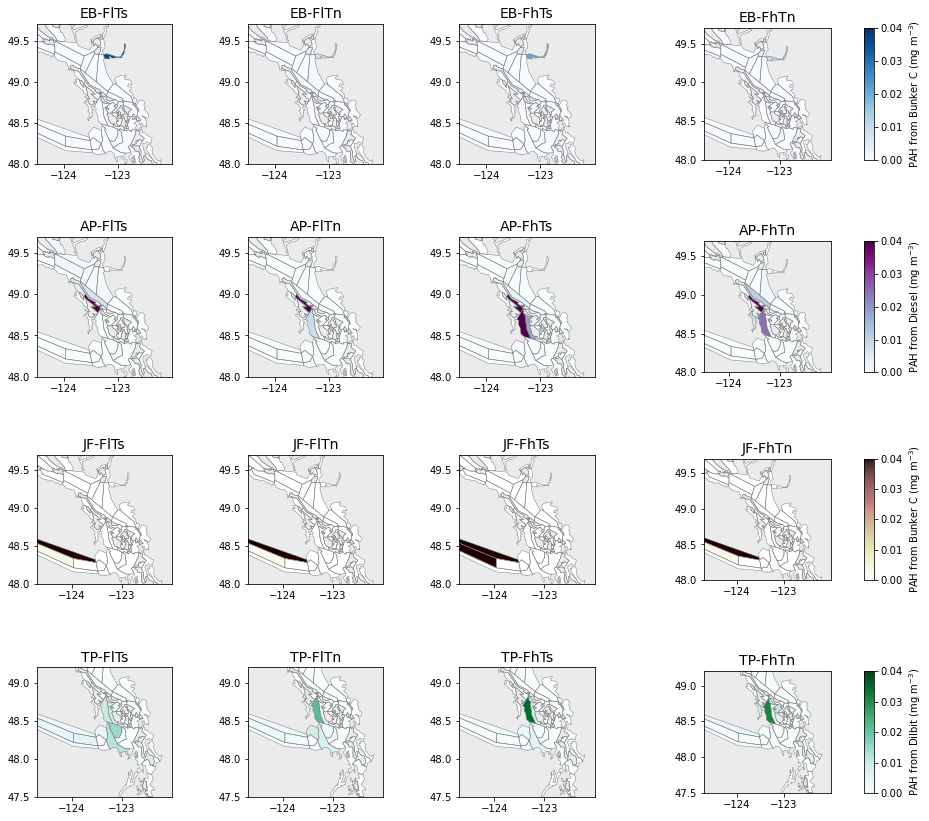

In [32]:

fig = plt.figure(figsize=(15, 15), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(4, 4, wspace=0.5, hspace=0.2, height_ratios=[1,1,1,1],width_ratios=[1,1,1,1.5])

oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_6a*-07-*_10000_WSFmean.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]
for file, oil_path in zip(oil_files, oil_paths):

    date = str(oil_path).split(sep = '_')[3]
    label = 'EB-'+ groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])]
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.01] #4% of maximum

    ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB') ##C0C0C0
    ax = data_df.plot(column = 'TPAH', ax=ax, cmap=cm.Blues, vmax=0.04)
    if position == 3:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", ) #pad=-0.5
        ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax, cmap=cm.Blues, vmax=0.04,
        legend_kwds={'label': 'PAH from Bunker C (mg m$^{-3}$)'}, legend=True,
        )
    ax.set_title(label, fontsize = 14) #loc='left'
    ax.set_xlim(-124.5)
    ax.set_ylim(48, 49.7)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')

oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_4a*-07-*_10000_WSFmean.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]
for file, oil_path in zip(oil_files, oil_paths):

    date = str(oil_path).split(sep = '_')[3]
    label = 'AP-'+ groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])]
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)
    
    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.01] #4% of maximum

    ax = fig.add_subplot(gs[1, position], facecolor = '#EBEBEB') ##C0C0C0
    ax = data_df.plot(column = 'TPAH', ax=ax, cmap=cm.BuPu, vmax=0.04)
    if position == 3:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", ) #pad=-0.5
        ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax, cmap=cm.BuPu, vmax=0.04,
        legend_kwds={'label': 'PAH from Diesel (mg m$^{-3}$)'}, legend=True,
        )
    ax.set_title(label, fontsize = 14) #loc='left'
    ax.set_xlim(-124.5)
    ax.set_ylim(48, 49.7)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')

oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_7a*-01-*_10000_WSFmean.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]
for file, oil_path in zip(oil_files, oil_paths):

    date = str(oil_path).split(sep = '_')[3]
    label = 'JF-'+ groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])]
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.01] #4% of maximum

    ax = fig.add_subplot(gs[2, position], facecolor = '#EBEBEB') ##C0C0C0
    ax = data_df.plot(column = 'TPAH', ax=ax, cmap=cm.pink_r, vmax=0.04)
    if position == 3:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", ) #pad=-0.5
        ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax, cmap=cm.pink_r, vmax=0.04,
        legend_kwds={'label': 'PAH from Bunker C (mg m$^{-3}$)'}, legend=True,
        )
    ax.set_title(label, fontsize = 14) #loc='left'
    ax.set_xlim(-124.7)
    ax.set_ylim(48, 49.7)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')

oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_5b*-01-*_10000_WSFmean.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]
for file, oil_path in zip(oil_files, oil_paths):

    date = str(oil_path).split(sep = '_')[3]
    label = 'TP-'+ groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])]
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.01] #4% of maximum

    ax = fig.add_subplot(gs[3, position], facecolor = '#EBEBEB') ##C0C0C0
    ax = data_df.plot(column = 'TPAH', ax=ax, cmap=cm.BuGn, vmax=0.04)
    if position == 3:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%") 
        ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax, cmap=cm.BuGn, vmax=0.04,
        legend_kwds={'label': 'PAH from Dilbit (mg m$^{-3}$)'}, legend=True,
        )
    ax.set_title(label, fontsize = 14) #loc='left'
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.2)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
#fig.supylabel('English Bay  Active Pass  Juan de Fuca Strait  Turn Point', fontsize = 16); #color=hex_colour


In [33]:
fig.savefig("Figures/spill-map-all-with-labels.png", dpi=300, bbox_inches='tight')